In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("production_demand_dataset.csv")
df.head()

,Date,Product_ID,Production,Sales,Inventory,Price,Promotion,Holiday,Demand
0,2025-01-01,P004,185,141,188,327.62,0,0,90
1,2025-01-02,P005,235,163,560,491.53,1,0,142
2,2025-01-03,P003,595,447,308,334.32,1,0,497
3,2025-01-04,P005,338,296,59,166.91,1,0,255
4,2025-01-05,P005,551,421,310,335.30,1,0,474


In [3]:
df.shape
df.columns


Index(['Date', 'Product_ID', 'Production', 'Sales', 'Inventory', 'Price',
       'Promotion', 'Holiday', 'Demand'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        500 non-null    object 
 1   Product_ID  500 non-null    object 
 2   Production  500 non-null    int64  
 3   Sales       500 non-null    int64  
 4   Inventory   500 non-null    int64  
 5   Price       500 non-null    float64
 6   Promotion   500 non-null    int64  
 7   Holiday     500 non-null    int64  
 8   Demand      500 non-null    int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 35.3+ KB


In [20]:
df.isnull().sum()

Date          0
Product_ID    0
Production    0
Sales         0
Inventory     0
Price         0
Promotion     0
Holiday       0
Demand        0
dtype: int64

In [21]:
df.describe()

,Production,Sales,Inventory,Price,Promotion,Holiday,Demand
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,333.50400,283.228000,315.166000,276.408560,0.306000,0.092000,258.196000
std,133.85636,122.639998,158.279421,130.641129,0.461291,0.289315,123.135707
min,75.00000,80.000000,50.000000,52.220000,0.000000,0.000000,0.000000
25%,214.75000,178.000000,182.750000,158.412500,0.000000,0.000000,154.750000
50%,337.50000,284.000000,317.000000,283.275000,0.000000,0.000000,262.000000
75%,449.25000,391.000000,444.250000,380.270000,1.000000,0.000000,358.000000
max,626.00000,496.000000,599.000000,499.740000,1.000000,1.000000,535.000000


In [4]:
df["Product_ID"].unique()
df["Product_ID"].value_counts()

Product_ID
P004    112
P001    109
P002     95
P005     93
P003     91
Name: count, dtype: int64

In [5]:
df["Date"] = pd.to_datetime(df["Date"])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        500 non-null    datetime64[ns]
 1   Product_ID  500 non-null    object        
 2   Production  500 non-null    int64         
 3   Sales       500 non-null    int64         
 4   Inventory   500 non-null    int64         
 5   Price       500 non-null    float64       
 6   Promotion   500 non-null    int64         
 7   Holiday     500 non-null    int64         
 8   Demand      500 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(1)
memory usage: 35.3+ KB


In [7]:
df.head()

,Date,Product_ID,Production,Sales,Inventory,Price,Promotion,Holiday,Demand
0,2025-01-01,P004,185,141,188,327.62,0,0,90
1,2025-01-02,P005,235,163,560,491.53,1,0,142
2,2025-01-03,P003,595,447,308,334.32,1,0,497
3,2025-01-04,P005,338,296,59,166.91,1,0,255
4,2025-01-05,P005,551,421,310,335.30,1,0,474


In [8]:
df.columns



Index(['Date', 'Product_ID', 'Production', 'Sales', 'Inventory', 'Price',
       'Promotion', 'Holiday', 'Demand'],
      dtype='object')

In [15]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

df["DayOfWeek"] = df["Date"].dt.dayofweek

In [16]:
df.columns

Index(['Date', 'Product_ID', 'Production', 'Sales', 'Inventory', 'Price',
       'Promotion', 'Holiday', 'Demand', 'Month', 'Day', 'DayOfWeek', 'Year'],
      dtype='object')

In [17]:
X = df[[
    "Production",
    "Sales",
    "Inventory",
    "Price",
    "Promotion",
    "Holiday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek"
]]

y = df["Demand"]

In [18]:
X.head()

,Production,Sales,Inventory,Price,Promotion,Holiday,Year,Month,Day,DayOfWeek
0,185,141,188,327.62,0,0,2025,1,1,2
1,235,163,560,491.53,1,0,2025,1,2,3
2,595,447,308,334.32,1,0,2025,1,3,4
3,338,296,59,166.91,1,0,2025,1,4,5
4,551,421,310,335.30,1,0,2025,1,5,6


In [19]:
y.head()

0     90
1    142
2    497
3    255
4    474
Name: Demand, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (400, 10)
X_test: (100, 10)
y_train: (400,)
y_test: (100,)


In [22]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pred = model.predict(X_test)

In [24]:
print(y_pred[:10])

[ 91.33810902 296.90951664 226.02440119  98.90782744 247.76698493
 268.67601502 131.68870593 267.85247936 157.02784948 401.96838793]


In [26]:
comparison = pd.DataFrame({"Actual Demand": y_test.values,"Predicted Demand": y_pred})
comparison.head(10)

,Actual Demand,Predicted Demand
0,82,91.338109
1,335,296.909517
2,225,226.024401
3,80,98.907827
4,227,247.766985
5,274,268.676015
6,150,131.688706
7,280,267.852479
8,189,157.027849
9,392,401.968388


In [30]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:" , r2)


MAE: 22.241221265175717
MSE: 802.6657895616084
RMSE: 28.331357001767643
R2: 0.9454697775041113


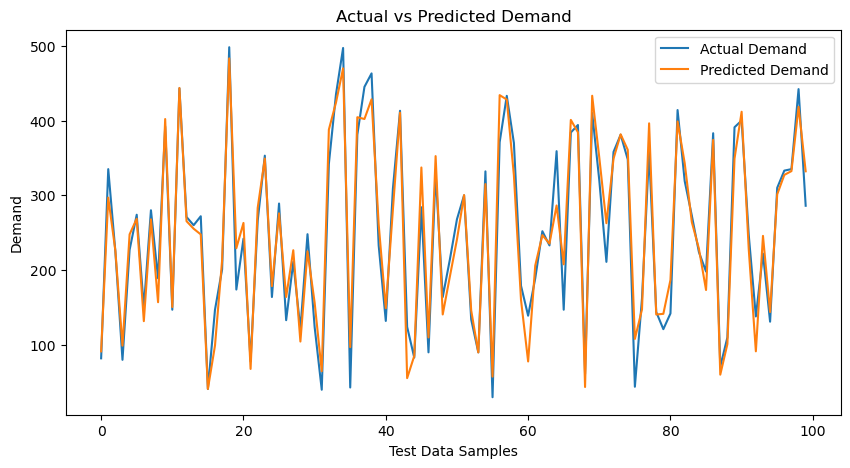

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.plot(y_test.values,label ="Actual Demand")
plt.plot(y_pred, label = "Predicted Demand")

plt.xlabel("Test Data Samples")
plt.ylabel("Demand")
plt.title("Actual vs Predicted Demand")
plt.legend()

plt.show()

In [32]:
from sklearn.ensemble import RandomForestRegressor

In [33]:
rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)

In [34]:
rf_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
rf_pred = rf_model.predict(X_test)

In [37]:
# Linear Regression
lr_mae = mean_absolute_error(y_test, y_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_r2 = r2_score(y_test, y_pred)

# Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

print("\nRandom Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Linear Regression
MAE : 22.241221265175717
RMSE: 28.331357001767643
R²  : 0.9454697775041113

Random Forest
MAE : 26.823100000000004
RMSE: 33.9095983609361
R²  : 0.9218825949665923
